# Lab 10 — La población estable de tu entidad

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 10: La población estable de tu entidad

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Cuatro partes. Se toma el **régimen** de tu entidad —tu fecundidad por edad del
lab 7 y tu mortalidad femenina por edad— y se le pregunta qué población
produciría si durara para siempre: su **tasa intrínseca de crecimiento** $r$
(la ecuación de Lotka, resuelta por bisección), su **distribución estable por
edad**, y la comparación con tu pirámide real.

Dos cosas que este laboratorio exige y los anteriores no:
- **Comprobar contra una entrega previa**: tu TNR de la parte 1 tiene que
  coincidir con la del lab 8. Si no coincide, el problema son los datos, no la
  teoría.
- **Resolver una ecuación sin fórmula cerrada**: la $r$ de Lotka se encuentra
  probando. Lo programas tú.

**Esto va a la Entrega 1** (bloque de crecimiento y bloque de pirámide).

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- tu entidad
FUENTE  = "Fecundidad: lab 7 (INEGI/CONAPO, 2023). Mortalidad femenina: CONAPO, Conciliación Demográfica y Proyecciones de la Población (defunciones y población femenina, 2023). Población femenina por edad: INEGI, Censo de Población y Vivienda 2020"   # <- fuentes: fecundidad (lab 7), mortalidad femenina y poblacion femenina por edad (INEGI/CONAPO, anio)

## Datos y herramientas

Tres insumos, en **17 grupos quinquenales** (0-4, 5-9, …, 75-79, 80+) porque la
población estable necesita todas las edades, no solo las fértiles:

1. Tus **tasas específicas de fecundidad** ₅fₓ de los siete grupos 15-49 (lab 7).
2. Tus **tasas de mortalidad femenina** ₅Mₓ en los 17 grupos. Los diez primeros
   son los que usaste en el lab 8; agrega los siete de 50 en adelante.
3. Tu **población femenina por edad** en 2020, 17 grupos (la mitad derecha de
   tu pirámide del lab 1/2).

`tabla17()` construye la tabla de vida femenina y devuelve la columna
₅Lₓ/l₀ (con el intervalo abierto como l₈₀/M₈₀). Es el procedimiento de los labs
3, 4 y 8, extendido a 17 grupos; se da hecho porque hoy el objetivo es otro.

Los datos de práctica son los de la **misma entidad de práctica del lab 9**
(la receptora, 2.11 millones de habitantes): su fecundidad y sus diez primeras
tasas femeninas son exactamente las del lab 8. No son datos reales.

In [57]:
GRUPOS = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49',
          '50-54','55-59','60-64','65-69','70-74','75-79','80+']
EDAD   = np.arange(0, 85, 5)          # edad inicial de cada grupo
MEDIO  = EDAD + 2.5                   # punto medio (para el 80+ es una aproximacion)
FERT   = slice(3, 10)                 # posiciones de los grupos 15-19 .. 45-49
FRAC_NINAS = 100 / 205                # 0.4878: razon de sexos al nacer 105
RAIZ = 100_000

# --- referencia NACIONAL (fecundidad y mortalidad femenina del lab 8, extendida a 80+) ---
F_NACIONAL  = np.array([0.0700, 0.1150, 0.1050, 0.0800, 0.0400, 0.0090, 0.0005])
MF_NACIONAL = np.array([0.00240, 0.00018, 0.00020, 0.00035, 0.00050, 0.00060, 0.00080, 0.00110, 0.00170, 0.00260,
                        0.0042, 0.0065, 0.0105, 0.0170, 0.0285, 0.0480, 0.1250])

# --- datos de PRACTICA (ilustrativos, no reales; la entidad del lab 9) ---------------
F_PRACTICA  = np.array([0.0850, 0.1250, 0.1000, 0.0700, 0.0320, 0.0070, 0.0005])
MF_PRACTICA = np.array([0.00480, 0.00036, 0.00040, 0.00070, 0.00100, 0.00120, 0.00160, 0.00220, 0.00340, 0.00520,
                        0.0046, 0.0068, 0.0105, 0.0165, 0.0265, 0.0440, 0.1150])
# mujeres por grupo de edad, 2020 (miles -> personas)
NF_PRACTICA = np.array([88, 90, 86, 84, 82, 92, 90, 80, 74, 68, 55, 46, 38, 30, 21, 13, 10]) * 1000


def tabla17(nMx, raiz=RAIZ):
    """Tabla de vida femenina abreviada en 17 grupos quinquenales (0-4 .. 80+).

    Devuelve (DataFrame completo, L) donde L = 5Lx / l0: los anios-persona vividos en
    cada grupo por cada recien nacida. Es el procedimiento de los labs 3 y 4:
      nqx = 5 nMx / (1 + 2.5 nMx) en los cerrados y 1 en el abierto
      nLx = 5 l(x+5) + 2.5 ndx     en los cerrados y l80 / M80 en el abierto
    """
    m = np.asarray(nMx, dtype=float)
    nqx = 5 * m / (1 + 2.5 * m)
    nqx[-1] = 1.0
    lx = np.zeros(17); lx[0] = raiz
    for i in range(16):
        lx[i + 1] = lx[i] * (1 - nqx[i])
    ndx = lx * nqx
    nLx = np.zeros(17)
    nLx[:-1] = 5 * lx[1:] + 2.5 * ndx[:-1]
    nLx[-1] = lx[-1] / m[-1]
    Tx = np.cumsum(nLx[::-1])[::-1]
    tab = pd.DataFrame({'grupo': GRUPOS, 'nMx': m, 'nqx': nqx, 'lx': lx, 'ndx': ndx,
                        'nLx': nLx, 'Tx': Tx, 'ex': Tx / lx})
    return tab, nLx / raiz

## Tus datos

Pega tus siete ₅fₓ, tus diecisiete ₅Mₓ femeninas y tus diecisiete grupos de
mujeres. Si dejas alguna lista vacía se usan los de práctica y el notebook lo
dice.

In [58]:
# TODO 0: pega tus datos.
mis_f  = [0.0500, 0.1000, 0.1000, 0.0700, 0.0350, 0.0090, 0.0005]     # 7 tasas de fecundidad, 15-19 .. 45-49 (las del lab 7)
mis_M  = [0.001788, 0.000139, 0.000216, 0.000369, 0.000458, 0.000521, 0.000655, 0.000954, 0.001490, 0.002403,
          0.003887, 0.006236, 0.009938, 0.015777, 0.024921, 0.039337, 0.091095]     # 17 tasas de mortalidad FEMENINA, 0-4 .. 80+ (por persona, no por mil)
mis_NF = [131891, 147045, 153042, 154341, 166909, 161994, 150225, 143900, 135279, 126657,
          108599, 83875, 68735, 49722, 34613, 22041, 25440]     # 17 grupos de MUJERES en 2020, 0-4 .. 80+

if len(mis_f) == 0 or len(mis_M) == 0 or len(mis_NF) == 0:
    f, M, NF = F_PRACTICA, MF_PRACTICA, NF_PRACTICA
    print("Usando los datos de PRACTICA. Sustituyelos por los de tu entidad.")
else:
    f, M, NF = np.asarray(mis_f, float), np.asarray(mis_M, float), np.asarray(mis_NF, float)
    print(f"Usando datos propios: {ENTIDAD}")

assert len(f) == 7 and len(M) == 17 and len(NF) == 17, "Faltan grupos: 7 tasas de fecundidad, 17 de mortalidad, 17 de poblacion"
tab, L = tabla17(M)
print("e0 femenina:", round(tab['ex'][0], 2))

Usando datos propios: Baja California
e0 femenina: 80.4


## Parte 1 — El régimen y su TNR  *(2.5 puntos)*

$$\text{TNR} = \sum_{x=15}^{45} 0.4878\;{}_5f_x\;\frac{{}_5L_x}{l_0}
\qquad\qquad
T = \frac{\sum_x (x+2.5)\,\big(0.4878\,{}_5f_x\,{}_5L_x/l_0\big)}{\text{TNR}}$$

La TNR es la que calculaste en el lab 8. **Tiene que coincidir**: si tus diez
primeras ₅Mₓ son las mismas, el número es el mismo.

In [59]:
# TODO 1.1: calcula la TGF, la TBR y la aportacion de cada grupo a la TNR
#   (0.4878 * f * L de ese grupo). Presenta la tabla con las tres columnas y la
#   aportacion, e imprime TGF, TBR y TNR.
L_fert = L[FERT]
aport  = FRAC_NINAS * f * L_fert
tgf = 5 * f.sum()
tbr = tgf * FRAC_NINAS
tnr = aport.sum()
df_tnr = pd.DataFrame({'grupo': GRUPOS[3:10], 'f (5fx)': f, 'frac_ninas': FRAC_NINAS,
                       'L (5Lx/l0)': L_fert, 'aportación_TNR': aport})
display(df_tnr.round(5))
print(f"TGF = {tgf:.4f}   TBR = {tbr:.4f}   TNR = {tnr:.4f}")

# TODO 1.2: COMPRUEBA que tu TNR coincide con la del lab 8 (escribe aqui el
#   numero del lab 8 y la diferencia). Si difiere, di por que antes de seguir.
TNR_LAB8 = 0.8745283166849622   # TNR de Baja California en el lab 8
print(f"\nTNR lab 8 = {TNR_LAB8:.6f} | TNR aquí = {tnr:.6f} | diferencia = {tnr - TNR_LAB8:.2e}")
print("¿Coincide?:", np.isclose(tnr, TNR_LAB8, atol=1e-6),
      "-> mismas 5fx del lab 7 y mismas diez primeras 5Mx del lab 8 (CONAPO 2023).")

# TODO 1.3: calcula la longitud media de generacion T y la tasa APROXIMADA
#   r_aprox = ln(TNR) / T, en por mil. Es la de la sesion 8; en la parte 2 la
#   vas a corregir.
T = (MEDIO[FERT] * aport).sum() / tnr
r_aprox = np.log(tnr) / T
print(f"\nLongitud media de generación T = {T:.2f} años")
print(f"r aproximada = ln(TNR)/T = {r_aprox*1000:.3f} por mil por año")

,grupo,f (5fx),frac_ninas,L (5Lx/l0),aportación_TNR
0,15-19,0.0500,0.4878,4.94215,0.12054
1,20-24,0.1000,0.4878,4.93195,0.24058
2,25-29,0.1000,0.4878,4.91989,0.23999
3,30-34,0.0700,0.4878,4.90545,0.16750
4,35-39,0.0350,0.4878,4.88576,0.08342
5,40-44,0.0090,0.4878,4.85602,0.02132
6,45-49,0.0005,0.4878,4.80904,0.00117


TGF = 1.8225   TBR = 0.8890   TNR = 0.8745

TNR lab 8 = 0.874528 | TNR aquí = 0.874528 | diferencia = -2.22e-16
¿Coincide?: True -> mismas 5fx del lab 7 y mismas diez primeras 5Mx del lab 8 (CONAPO 2023).

Longitud media de generación T = 27.05 años
r aproximada = ln(TNR)/T = -4.956 por mil por año


## Parte 2 — La tasa intrínseca de Lotka  *(2.5 puntos)*

$$y(r) = \sum_{x=15}^{45} e^{-r(x+2.5)}\;0.4878\;{}_5f_x\;\frac{{}_5L_x}{l_0}
\qquad\text{y se busca } r \text{ tal que } y(r) = 1.$$

Nota que $y(0) = \text{TNR}$. La función $y$ **decrece** en $r$: si $y(r) > 1$ el
$r$ de prueba es chico; si $y(r) < 1$, es grande. Con eso basta para encontrar
la solución por **bisección**.

In [60]:
# TODO 2.1: escribe la funcion y(r) y verifica EN CODIGO que y(0) reproduce tu
#   TNR (imprime las dos y la diferencia).
def y(r):
    return np.sum(np.exp(-r * MEDIO[FERT]) * FRAC_NINAS * f * L_fert)

print(f"y(0) = {y(0):.6f} | TNR = {tnr:.6f} | diferencia = {y(0) - tnr:.2e} -> ¿iguales?: {np.isclose(y(0), tnr)}")

# TODO 2.2: encuentra r por BISECCION en el intervalo [-0.1, 0.1] con al menos
#   60 iteraciones (o hasta que |y(r) - 1| < 1e-10). Imprime r en por mil, la
#   diferencia con tu r_aprox de la parte 1, y di si la aproximacion de la
#   sesion 8 fue buena en tu caso y por que (pista: que tan lejos de 1 esta tu TNR).
a, b_ = -0.1, 0.1
for it in range(200):
    r_mid = (a + b_) / 2
    if y(r_mid) > 1:      # y decrece en r: r de prueba demasiado chico
        a = r_mid
    else:
        b_ = r_mid
    if it >= 59 and abs(y(r_mid) - 1) < 1e-10:
        break
r = (a + b_) / 2
print(f"\nBisección: {it + 1} iteraciones, y(r) - 1 = {y(r) - 1:.2e}")
print(f"r intrínseca (Lotka) = {r*1000:.4f} por mil por año")
print(f"r aproximada (sesión 8) = {r_aprox*1000:.4f} por mil | diferencia = {(r - r_aprox)*1000:.4f} por mil "
      f"({abs(r/r_aprox - 1)*100:.2f}%)")
print(f"La aproximación fue buena. La TNR ({tnr:.3f}) está a solo {abs(1 - tnr)*100:.1f}% de 1, así que ln(TNR)/T "
      "casi no se separa de la solución exacta. El error de aproximación crece con la distancia de la TNR a 1 "
      "y con la dispersión de las edades de la fecundidad alrededor de T.")

# TODO 2.3: traduce r a dos cosas: el factor por quinquenio lambda = exp(5 r)
#   —el que en la sesion 28 sera el valor propio dominante de la matriz de
#   Leslie— y el tiempo de duplicacion (o de reduccion a la mitad si r < 0),
#   ln(2) / |r|, en anios. Imprimelos con sus nombres.
lam = np.exp(5 * r)
t_mitad = np.log(2) / abs(r)
print(f"\nFactor por quinquenio lambda = exp(5r) = {lam:.5f} (la población se multiplica por {lam:.4f} cada 5 años)")
print(f"Tiempo de {'duplicación' if r > 0 else 'reducción a la mitad'} = ln(2)/|r| = {t_mitad:.1f} años")

y(0) = 0.874528 | TNR = 0.874528 | diferencia = 0.00e+00 -> ¿iguales?: True

Bisección: 60 iteraciones, y(r) - 1 = 2.22e-16
r intrínseca (Lotka) = -4.9379 por mil por año
r aproximada (sesión 8) = -4.9564 por mil | diferencia = 0.0185 por mil (0.37%)
La aproximación fue buena. La TNR (0.875) está a solo 12.5% de 1, así que ln(TNR)/T casi no se separa de la solución exacta. El error de aproximación crece con la distancia de la TNR a 1 y con la dispersión de las edades de la fecundidad alrededor de T.

Factor por quinquenio lambda = exp(5r) = 0.97561 (la población se multiplica por 0.9756 cada 5 años)
Tiempo de reducción a la mitad = ln(2)/|r| = 140.4 años


## Parte 3 — La distribución estable contra tu pirámide  *(2.5 puntos)*

$${}_5c^*_x = b\,e^{-r(x+2.5)}\,\frac{{}_5L_x}{l_0},
\qquad
b = \frac{1}{\sum_x e^{-r(x+2.5)}\,{}_5L_x/l_0}.$$

$b$ es la tasa bruta de natalidad de la población estable (por mujer, o sea
hijas por mujer al año), y $d^* = b - r$ su tasa bruta de mortalidad.

Suma de c* = 1.0000000000 -> ¿suma 1?: True
b (natalidad estable)  = 10.06 por mil
d* = b - r (mortalidad estable) = 14.99 por mil


,grupo,c real,c* estable,c / c*
0,0-4,0.0707,0.0507,1.3960
1,5-9,0.0789,0.0517,1.5257
2,10-14,0.0821,0.0529,1.5506
3,15-19,0.0828,0.0542,1.5279
4,20-24,0.0895,0.0554,1.6153
5,25-29,0.0869,0.0567,1.5333
6,30-34,0.0806,0.0579,1.3913
7,35-39,0.0772,0.0591,1.3054
8,40-44,0.0726,0.0602,1.2046
9,45-49,0.0679,0.0611,1.1111


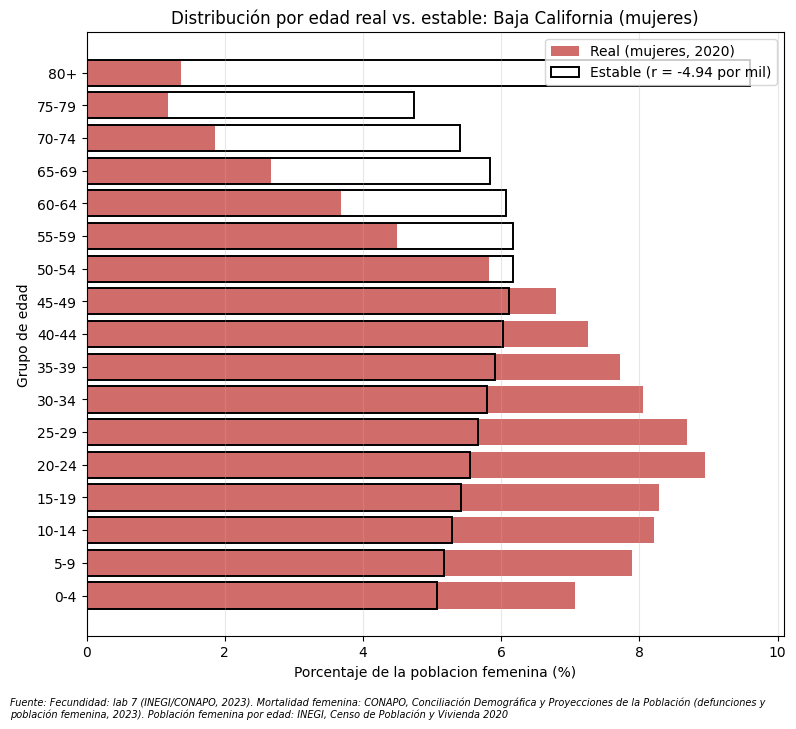

In [51]:
# TODO 3.1: calcula la distribucion estable c* para los 17 grupos y verifica EN
#   CODIGO que suma 1. Imprime b y d* = b - r en por mil.
pesos = np.exp(-r * MEDIO) * L
b = 1 / pesos.sum()
c_est = b * pesos
d_est = b - r
print(f"Suma de c* = {c_est.sum():.10f} -> ¿suma 1?: {np.isclose(c_est.sum(), 1)}")
print(f"b (natalidad estable)  = {b*1000:.2f} por mil")
print(f"d* = b - r (mortalidad estable) = {d_est*1000:.2f} por mil")

# TODO 3.2: calcula la distribucion REAL de tu poblacion femenina, c = NF / sum(NF),
#   y pon en una tabla, una junto a otra, c real y c* estable, con la razon
#   c / c*. Agrega tres renglones-resumen: % de menores de 15, % de 60 y mas, y
#   edad media (usa MEDIO), para las dos distribuciones.
c_real = NF / NF.sum()
df_dist = pd.DataFrame({'grupo': GRUPOS, 'c real': c_real, 'c* estable': c_est, 'c / c*': c_real / c_est})
resumen = pd.DataFrame({
    'grupo': ['% menores de 15', '% 60 y mas', 'edad media'],
    'c real': [c_real[:3].sum()*100, c_real[12:].sum()*100, (MEDIO*c_real).sum()],
    'c* estable': [c_est[:3].sum()*100, c_est[12:].sum()*100, (MEDIO*c_est).sum()],
})
resumen['c / c*'] = resumen['c real'] / resumen['c* estable']
display(pd.concat([df_dist, resumen], ignore_index=True).round(4))

# TODO 3.3: grafica las dos distribuciones como barras horizontales (barh) con
#   los grupos en el eje vertical: la real llena y la estable como contorno o
#   al lado. Ejes etiquetados, titulo con la entidad, leyenda y fuente.
ypos = np.arange(17)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(ypos, c_real * 100, color='#c85450', alpha=0.85, label='Real (mujeres, 2020)')
ax.barh(ypos, c_est * 100, fill=False, edgecolor='black', linewidth=1.4, label=f'Estable (r = {r*1000:.2f} por mil)')
ax.set_yticks(ypos); ax.set_yticklabels(GRUPOS)
ax.set_xlabel('Porcentaje de la poblacion femenina (%)')
ax.set_ylabel('Grupo de edad')
ax.set_title(f'Distribución por edad real vs. estable: {ENTIDAD} (mujeres)')
ax.legend(); ax.grid(axis='x', alpha=0.3)
fig.text(0.01, -0.03, f'Fuente: {FUENTE}', fontsize=7, style='italic', wrap=True)
plt.tight_layout(); plt.show()

## Parte 4 — El argumento, con sus cuatro piezas  *(2.5 puntos)*

Aquí conectas con el lab 9: su tasa de crecimiento total, su tasa de migración
neta y su tasa de crecimiento natural, todas por mil al año.

In [61]:
# TODO 4.1 — EL VEREDICTO DE LARGO PLAZO
# Di que implica tu regimen A LA LARGA: signo de r, tiempo de duplicacion o de
# reduccion a la mitad, y como se lee junto a tu TNR del lab 8 (la misma cosa
# por generacion y por anio). Usa la palabra «intrinseca» y di que NO es la
# tasa a la que tu entidad crece hoy.
print(f"La tasa intrínseca de crecimiento de {ENTIDAD} es r = {r*1000:.2f} por mil por año: Negativa.")
print(f"Si su régimen de fecundidad y mortalidad de hoy durara para siempre, sin migración, la población "
      f"se reduciría a la mitad cada {t_mitad:.0f} años (lambda = {lam:.4f} por quinquenio).")
print(f"Es la misma lectura que la TNR del lab 8 ({tnr:.4f} < 1), solo que por año y no por generación. "
      f"Cada generación es {(1-tnr)*100:.1f}% más chica que la anterior y, como una generación dura T = {T:.1f} "
      f"años, eso equivale a {r*1000:.2f} por mil al año.")
print("Esta tasa intrínseca es la del regimen a la larga, una vez que la estructura"
      " por edad se estabiliza y sin migracion, no a la que la entidad crece hoy")

La tasa intrínseca de crecimiento de Baja California es r = -4.94 por mil por año: Negativa.
Si su régimen de fecundidad y mortalidad de hoy durara para siempre, sin migración, la población se reduciría a la mitad cada 140 años (lambda = 0.9756 por quinquenio).
Es la misma lectura que la TNR del lab 8 (0.8745 < 1), solo que por año y no por generación. Cada generación es 12.5% más chica que la anterior y, como una generación dura T = 27.1 años, eso equivale a -4.94 por mil al año.
Esta tasa intrínseca es la del regimen a la larga, una vez que la estructura por edad se estabiliza y sin migracion, no a la que la entidad crece hoy


In [62]:
# TODO 4.2 — LA BRECHA
# Escribe aqui tus tres tasas del lab 9 (crecimiento total, migracion neta y
# crecimiento natural, por mil) y reparte la brecha entre tu r observada y tu r
# intrinseca en DOS pedazos: migracion (la de migracion neta) y estructura por
# edad (crecimiento natural observado menos r intrinseca). Da los dos numeros.
r_total_lab9    = 25.59   # por mil
r_migracion_lab9 = 13.79  # por mil
r_natural_lab9  = 11.80   # por mil

r_int_mil = r * 1000
brecha = r_total_lab9 - r_int_mil
pedazo_mig = r_migracion_lab9
pedazo_est = r_natural_lab9 - r_int_mil
print(f"r observada (lab 9) = {r_total_lab9:.2f} por mil | r intrínseca = {r_int_mil:.2f} por mil")
print(f"Brecha total = {brecha:.2f} por mil, repartida en:")
print(f"  Migración (migración neta): {pedazo_mig:.2f} por mil ({pedazo_mig/brecha*100:.1f}%)")
print(f"  Estructura por edad (natural observado - intrínseca): {pedazo_est:.2f} por mil ({pedazo_est/brecha*100:.1f}%)")
print(f"Comprobación: {pedazo_mig:.2f} + {pedazo_est:.2f} = {pedazo_mig + pedazo_est:.2f} -> ¿igual a la brecha?: "
      f"{np.isclose(pedazo_mig + pedazo_est, brecha)}")
print("Importante mencionar que las tasas del lab 9 son de ambos sexos y la r intrínseca es femenina; se toma como aproximación.")

r observada (lab 9) = 25.59 por mil | r intrínseca = -4.94 por mil
Brecha total = 30.53 por mil, repartida en:
  Migración (migración neta): 13.79 por mil (45.2%)
  Estructura por edad (natural observado - intrínseca): 16.74 por mil (54.8%)
Comprobación: 13.79 + 16.74 = 30.53 -> ¿igual a la brecha?: True
Importante mencionar que las tasas del lab 9 son de ambos sexos y la r intrínseca es femenina; se toma como aproximación.


In [63]:
# TODO 4.3 — LA ESTRUCTURA
# Con la tabla de la parte 3, di si tu entidad es mas joven o mas vieja que su
# estable (menores de 15, 60 y mas, edad media) y que significa eso para los
# proximos veinte anios: ¿va a seguir creciendo aunque su regimen no lo
# justifique, o al reves?
em_real, em_est = (MEDIO*c_real).sum(), (MEDIO*c_est).sum()
print(f"Menores de 15: {c_real[:3].sum()*100:.1f}% real vs {c_est[:3].sum()*100:.1f}% estable")
print(f"60 y más: {c_real[12:].sum()*100:.1f}% real vs {c_est[12:].sum()*100:.1f}% estable")
print(f"Edad media: {em_real:.1f} años real vs {em_est:.1f} años estable")
print(f"\n{ENTIDAD} es bastante más joven que su población estable, puesto que tiene menos personas mayores y concentra a las "
      "mujeres en edades reproductivas (15-49). Por eso, hoy nacen más de las que mueren aunque cada mujer no "
      "alcance a reemplazarse: es inercia demográfica (momentum).")
print("En los próximos veinte años, la entidad seguirá creciendo de forma natural, aunque su régimen no lo "
      "justifique, porque las cohortes grandes de mujeres de 15-34 años están entrando o siguen en la edad fértil. "
      "Conforme envejezcan, la natalidad bajará, la mortalidad subirá hacia el nivel estable "
      f"(d* = {d_est*1000:.1f} por mil) y el crecimiento natural irá cayendo hacia la r intrínseca negativa.")

Menores de 15: 23.2% real vs 15.5% estable
60 y más: 10.8% real vs 31.7% estable
Edad media: 32.6 años real vs 44.5 años estable

Baja California es bastante más joven que su población estable, puesto que tiene menos personas mayores y concentra a las mujeres en edades reproductivas (15-49). Por eso, hoy nacen más de las que mueren aunque cada mujer no alcance a reemplazarse: es inercia demográfica (momentum).
En los próximos veinte años, la entidad seguirá creciendo de forma natural, aunque su régimen no lo justifique, porque las cohortes grandes de mujeres de 15-34 años están entrando o siguen en la edad fértil. Conforme envejezcan, la natalidad bajará, la mortalidad subirá hacia el nivel estable (d* = 15.0 por mil) y el crecimiento natural irá cayendo hacia la r intrínseca negativa.


In [64]:
# TODO 4.4 — EL SUPUESTO
# La poblacion estable es un MODELO, no una identidad. Nombra los tres
# supuestos (poblacion cerrada, un solo sexo, regimen constante) y di cual de
# ellos es el mas falso para TU entidad y por que, con un numero del lab 9 si
# aplica.
print("(1) población cerrada, sin migración; (2) modelo de un solo sexo (solo mujeres y "
      "sus hijas); (3) régimen constante de fecundidad y mortalidad para siempre.")
print(f"\nEl más falso para {ENTIDAD} es el de población cerrada. En el lab 9, su migración neta fue de "
      f"{r_migracion_lab9:.2f} por mil al año, más que su crecimiento natural ({r_natural_lab9:.2f}) y "
      f"{pedazo_mig/brecha*100:.0f}% de la brecha con la r intrínseca; el saldo neto 2015-2020 fue de unas 244 mil "
      "personas, 6.5% de la población de 2020.")
print("Además, la migración llega concentrada en edades jovenes y laborales, así que no solo agrega gente, "
      "sino que rejuvenece la pirámide y la aleja todavía más de la estable. Una entidad fronteriza y receptora nunca "
      "va a converger a la distribución estable mientras sigan esos flujos.")

(1) población cerrada, sin migración; (2) modelo de un solo sexo (solo mujeres y sus hijas); (3) régimen constante de fecundidad y mortalidad para siempre.

El más falso para Baja California es el de población cerrada. En el lab 9, su migración neta fue de 13.79 por mil al año, más que su crecimiento natural (11.80) y 45% de la brecha con la r intrínseca; el saldo neto 2015-2020 fue de unas 244 mil personas, 6.5% de la población de 2020.
Además, la migración llega concentrada en edades jovenes y laborales, así que no solo agrega gente, sino que rejuvenece la pirámide y la aleja todavía más de la estable. Una entidad fronteriza y receptora nunca va a converger a la distribución estable mientras sigan esos flujos.


## Cierre y entrega

**Checklist:**
- [ ] Mi TNR coincide con la del lab 8 (comprobado, no supuesto).
- [ ] La verificación $y(0) = \text{TNR}$ está **impresa**.
- [ ] La bisección converge y reporté $r$ en **por mil**, con su signo.
- [ ] $\lambda = e^{5r}$ y el tiempo de duplicación tienen nombre y unidades.
- [ ] La distribución estable **suma 1** (verificado en código).
- [ ] La brecha del 4.2 está partida en migración y estructura, con números.

**Cómo se entrega:** en Colab, `Archivo → Descargar → Descargar .ipynb`, y
arrastra ese archivo al sistema. **El archivo, no el enlace.** Ejecuta el
notebook completo antes de subirlo.

Tienes **dos intentos**. Guarda este notebook: la $r$ intrínseca y la
distribución estable van a la Entrega 1 y el lab 11 las vuelve a usar.